# Yellow Dust Dataset - Preprocessing and EDA for V5 additional features

Contains China and Japan data. Yellow dust dataset from the Copernicus Atmosphere Monitoring Service.

## Processing first, renaming the columns to match other datasets

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import h3
from datetime import timezone

In [28]:
csv_path = "/home/julia/smoglens/data/yellow_dust_sfc.csv"
df = pd.read_csv(csv_path)

print("Initial shape:", df.shape)
print (df.head())
print ("Info: ")
df.info()

Initial shape: (6879672, 12)
            valid_time  latitude  longitude       u10       v10        t2m  \
0  2023-07-14 00:00:00      49.5      70.00  4.084112 -4.410157  292.92140   
1  2023-07-14 00:00:00      49.5      70.75  4.444952 -2.319825  293.97900   
2  2023-07-14 00:00:00      49.5      71.50  3.315069  0.891601  295.87450   
3  2023-07-14 00:00:00      49.5      72.25  1.098272  3.589354  297.51610   
4  2023-07-14 00:00:00      49.5      73.00 -0.573114  4.272948  297.07275   

   bcaod550  duaod550       lsm         pm2p5          pm10         sp  
0  0.007753  0.033607  0.989188  3.769855e-10  5.247784e-10  95463.766  
1  0.007878  0.046202  0.995354  1.591616e-12  2.273737e-12  95159.766  
2  0.007857  0.056740  0.994766  2.273737e-13  2.273737e-13  94840.766  
3  0.007964  0.062363  0.992191  9.906671e-10  1.457238e-09  94420.766  
4  0.008114  0.060853  0.990747  3.713240e-09  5.428092e-09  93657.766  
Info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6879672

### Meaning of column abbreviations

- **Shape:** 6,879,672 rows × 12 columns.
- **Columns:**  
  - `timestamp` (datetime): Measurement time (UTC).
  - `lat`, `lon`: Geographic coordinates.
  - `u10`, `v10`: Wind components at 10m (m/s).
  - `t2m`: Temperature at 2m (K).
  - `bcaod550`: Black carbon aerosol optical depth.
  - `duaod550`: Dust aerosol optical depth.
  - `lsm`: Land-sea mask (1=land, 0=sea).
  - `pm25`, `pm10`: Particulate matter concentrations (µg/m³).
  - `sp`: Surface pressure (Pa).

## Reassign Columns

In [29]:
df['timestamp'] = pd.to_datetime(df['valid_time'], utc=True)
df.drop(columns=['valid_time'], inplace=True)
print(df.head())

   latitude  longitude       u10       v10        t2m  bcaod550  duaod550  \
0      49.5      70.00  4.084112 -4.410157  292.92140  0.007753  0.033607   
1      49.5      70.75  4.444952 -2.319825  293.97900  0.007878  0.046202   
2      49.5      71.50  3.315069  0.891601  295.87450  0.007857  0.056740   
3      49.5      72.25  1.098272  3.589354  297.51610  0.007964  0.062363   
4      49.5      73.00 -0.573114  4.272948  297.07275  0.008114  0.060853   

        lsm         pm2p5          pm10         sp                 timestamp  
0  0.989188  3.769855e-10  5.247784e-10  95463.766 2023-07-14 00:00:00+00:00  
1  0.995354  1.591616e-12  2.273737e-12  95159.766 2023-07-14 00:00:00+00:00  
2  0.994766  2.273737e-13  2.273737e-13  94840.766 2023-07-14 00:00:00+00:00  
3  0.992191  9.906671e-10  1.457238e-09  94420.766 2023-07-14 00:00:00+00:00  
4  0.990747  3.713240e-09  5.428092e-09  93657.766 2023-07-14 00:00:00+00:00  


In [30]:
df.rename(columns={
    'latitude': 'lat',
    'longitude': 'lon',
    'pm2p5': 'pm25',
    'pm10': 'pm10'
}, inplace=True)

print (df.head())

    lat    lon       u10       v10        t2m  bcaod550  duaod550       lsm  \
0  49.5  70.00  4.084112 -4.410157  292.92140  0.007753  0.033607  0.989188   
1  49.5  70.75  4.444952 -2.319825  293.97900  0.007878  0.046202  0.995354   
2  49.5  71.50  3.315069  0.891601  295.87450  0.007857  0.056740  0.994766   
3  49.5  72.25  1.098272  3.589354  297.51610  0.007964  0.062363  0.992191   
4  49.5  73.00 -0.573114  4.272948  297.07275  0.008114  0.060853  0.990747   

           pm25          pm10         sp                 timestamp  
0  3.769855e-10  5.247784e-10  95463.766 2023-07-14 00:00:00+00:00  
1  1.591616e-12  2.273737e-12  95159.766 2023-07-14 00:00:00+00:00  
2  2.273737e-13  2.273737e-13  94840.766 2023-07-14 00:00:00+00:00  
3  9.906671e-10  1.457238e-09  94420.766 2023-07-14 00:00:00+00:00  
4  3.713240e-09  5.428092e-09  93657.766 2023-07-14 00:00:00+00:00  


In [35]:
print(df['timestamp'].min())
print(df['timestamp'].max())
print(df['month'].unique())
print(df['timestamp'].dt.month.value_counts().sort_index())

2023-07-14 00:00:00+00:00
2023-12-31 21:00:00+00:00
[ 7  8  9 10 11 12]
timestamp
7      724176
8     1247192
9     1206960
10    1247192
11    1206960
12    1247192
Name: count, dtype: int64


## EDA --- Step 1: Data Overview ---

In [31]:
print("Shape:", df.shape)
print("Memory usage (MB):", df.memory_usage(deep=True).sum() / 1e6)
print("Time range:", df['timestamp'].min(), "to", df['timestamp'].max())
print("Unique locations (lat, lon):", df[['lat', 'lon']].drop_duplicates().shape[0])

print("\nMissing values per column:\n", df.isnull().mean().round(3) * 100)
print("\nFirst 5 rows:\n", df.head())


Shape: (6879672, 12)
Memory usage (MB): 660.44864
Time range: 2023-07-14 00:00:00+00:00 to 2023-12-31 21:00:00+00:00
Unique locations (lat, lon): 5029

Missing values per column:
 lat          0.0
lon          0.0
u10          0.0
v10          0.0
t2m          0.0
bcaod550     0.0
duaod550     0.0
lsm          0.0
pm25         0.0
pm10         0.0
sp           0.0
timestamp    0.0
dtype: float64

First 5 rows:
     lat    lon       u10       v10        t2m  bcaod550  duaod550       lsm  \
0  49.5  70.00  4.084112 -4.410157  292.92140  0.007753  0.033607  0.989188   
1  49.5  70.75  4.444952 -2.319825  293.97900  0.007878  0.046202  0.995354   
2  49.5  71.50  3.315069  0.891601  295.87450  0.007857  0.056740  0.994766   
3  49.5  72.25  1.098272  3.589354  297.51610  0.007964  0.062363  0.992191   
4  49.5  73.00 -0.573114  4.272948  297.07275  0.008114  0.060853  0.990747   

           pm25          pm10         sp                 timestamp  
0  3.769855e-10  5.247784e-10  95463.766 

## --- Step 2: Data Quality Assessment ---

In [32]:
# Outlier detection
import numpy as np
for col in ['pm25', 'pm10', 't2m', 'u10', 'v10', 'sp']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    outliers = ((df[col] < (q1 - 1.5 * iqr)) | (df[col] > (q3 + 1.5 * iqr))).sum()
    print(f"{col}: {outliers} outliers ({outliers/len(df)*100:.2f}%)")

# Value range checks
print("Negative PM2.5:", (df['pm25'] < 0).sum())
print("Negative PM10:", (df['pm10'] < 0).sum())
print("Temperature out of range (<200K or >330K):", ((df['t2m'] < 200) | (df['t2m'] > 330)).sum())
print("LSM out of [0,1]:", ((df['lsm'] < 0) | (df['lsm'] > 1)).sum())

# Duplicates
dupes = df.duplicated(subset=['timestamp', 'lat', 'lon']).sum()
print("Duplicate records (timestamp, lat, lon):", dupes)


pm25: 752067 outliers (10.93%)
pm10: 749039 outliers (10.89%)
t2m: 142705 outliers (2.07%)
u10: 551074 outliers (8.01%)
v10: 504076 outliers (7.33%)
sp: 641153 outliers (9.32%)
Negative PM2.5: 0
Negative PM10: 0
Temperature out of range (<200K or >330K): 0
LSM out of [0,1]: 0
Duplicate records (timestamp, lat, lon): 0


### Data Consistency
- **Value Ranges:**  
  - PM2.5/PM10 should be ≥ 0.
  - Temperature (t2m) should be within realistic atmospheric bounds.
  - lsm between 0 and 1.

The relatively high percentage of outliers in PM2.5 and PM10 suggests substantial variability or the presence of extreme pollution events in the dataset. Wind and pressure variables also show notable outlier rates, which may reflect meteorological extremes or data quality issues. Temperature outliers are much less frequent, indicating more stable measurements.

No negative or physically impossible values were found for PM2.5, PM10, temperature, or land-sea mask, indicating good basic data quality. There are also no duplicate records for the combination of timestamp, latitude, and longitude, confirming uniqueness of observations.

## --- Step 3: Temporal Patterns ---

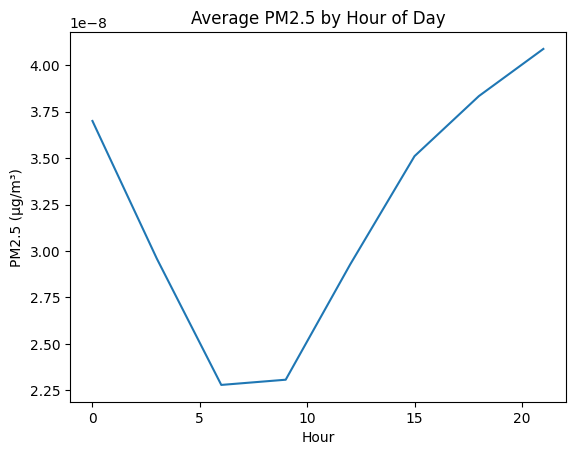

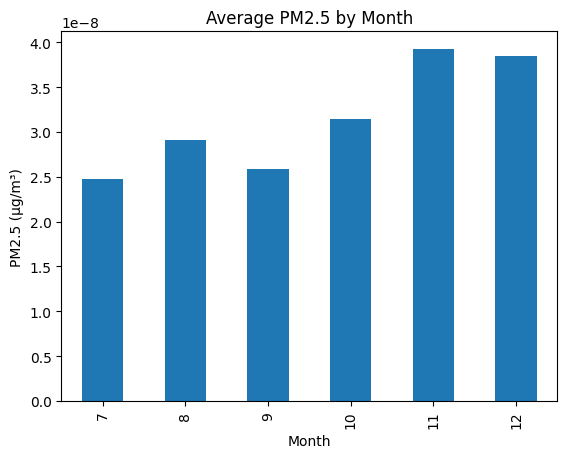

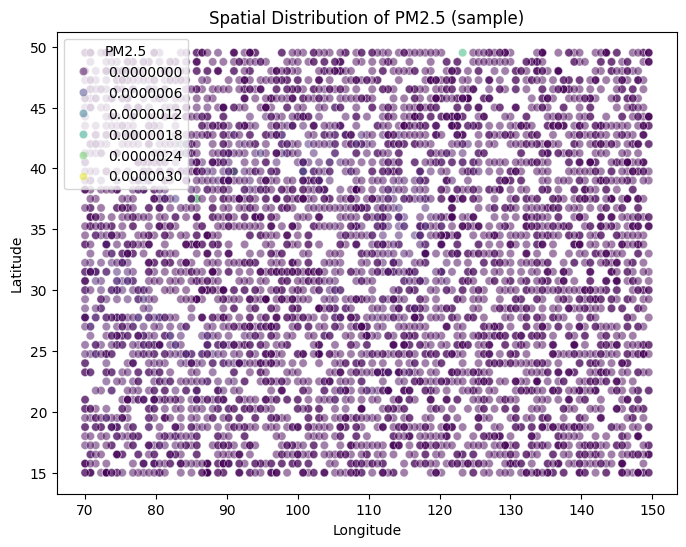

In [33]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['weekday'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month

# Hourly pattern
hourly_pm25 = df.groupby('hour')['pm25'].mean()
hourly_pm25.plot(title='Average PM2.5 by Hour of Day', xlabel='Hour', ylabel='PM2.5 (µg/m³)')
plt.show()

# Monthly pattern
monthly_pm25 = df.groupby('month')['pm25'].mean()
monthly_pm25.plot(kind='bar', title='Average PM2.5 by Month', xlabel='Month', ylabel='PM2.5 (µg/m³)')
plt.show()

# --- Step 4: Spatial Patterns ---

plt.figure(figsize=(8,6))
sns.scatterplot(data=df.sample(5000), x='lon', y='lat', hue='pm25', palette='viridis', alpha=0.5)
plt.title('Spatial Distribution of PM2.5 (sample)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='PM2.5')
plt.show()


## --- Step 5: Feature Relationships ---

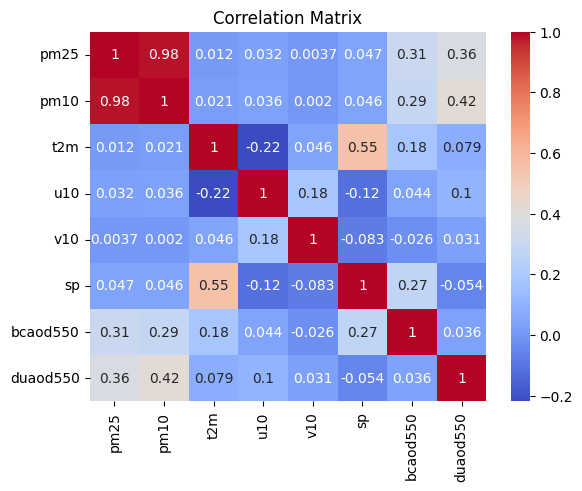

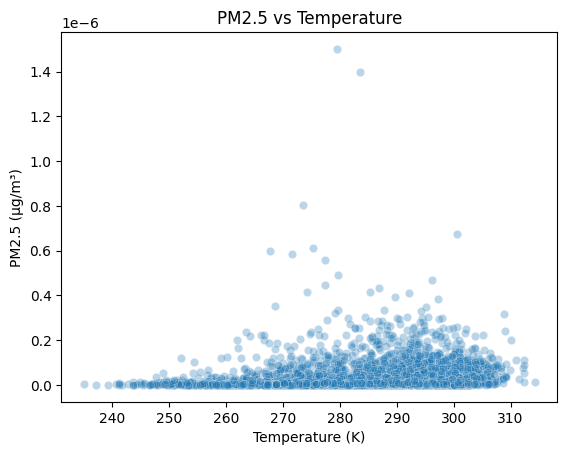

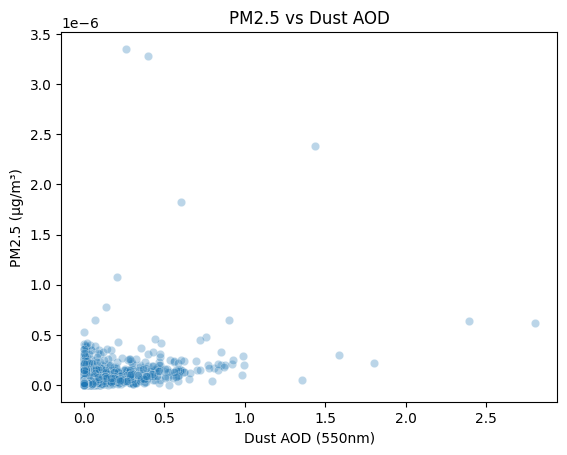

In [34]:

corr = df[['pm25', 'pm10', 't2m', 'u10', 'v10', 'sp', 'bcaod550', 'duaod550']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

sns.scatterplot(x='t2m', y='pm25', data=df.sample(5000), alpha=0.3)
plt.title('PM2.5 vs Temperature')
plt.xlabel('Temperature (K)')
plt.ylabel('PM2.5 (µg/m³)')
plt.show()

sns.scatterplot(x='duaod550', y='pm25', data=df.sample(5000), alpha=0.3)
plt.title('PM2.5 vs Dust AOD')
plt.xlabel('Dust AOD (550nm)')
plt.ylabel('PM2.5 (µg/m³)')
plt.show()